# Лабораторная работа №4

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  
**Вариант:** 2

**Тема:** Методы поиска условного экстремума


In [1]:
# Импорт необходимых библиотек для выполнения лабораторной работы

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from scipy.optimize import minimize, minimize_scalar

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Задание параметров варианта и определение тестовой функции Розенброка

variant = 2

a = 150
b = 2
f0 = 100
n = 3

def rosenbrock_function(x):
    x = np.array(x, dtype=float)
    value = 0.0
    for i in range(n - 1):
        value += a * (x[i + 1] - x[i] ** 2) ** 2 + b * (x[i] - 1) ** 2
    return value + f0

x_star_unconstrained = np.ones(n)
f_star_unconstrained = rosenbrock_function(x_star_unconstrained)

print("Variant:", variant)
print("a =", a)
print("b =", b)
print("f0 =", f0)
print("n =", n)
print("Unconstrained theoretical minimum point:", x_star_unconstrained)
print("Function value at unconstrained theoretical minimum:", f_star_unconstrained)

Variant: 2
a = 150
b = 2
f0 = 100
n = 3
Unconstrained theoretical minimum point: [1. 1. 1.]
Function value at unconstrained theoretical minimum: 100.0


In [3]:
# Определение функций ограничений для выбранного варианта

def constraints(x):
    x = np.array(x, dtype=float)
    g1 = x[0] ** 2 + x[1] ** 2 + x[2] ** 2 - 1
    g2 = -x[0]
    g3 = -x[1]
    g4 = -x[2]
    return np.array([g1, g2, g3, g4], dtype=float)

def constraint_violation(x):
    g = constraints(x)
    return np.sum(np.maximum(g, 0.0) ** 2)

def is_feasible(x, tolerance=1e-8):
    return np.all(constraints(x) <= tolerance)

test_points = [
    np.array([1.0, 1.0, 1.0]),
    np.array([0.5, 0.5, 0.5]),
    np.array([0.2, 0.3, 0.4])
]

for point in test_points:
    print("Point:", point)
    print("g(x):", constraints(point))
    print("Constraint violation:", constraint_violation(point))
    print("Feasible:", is_feasible(point))
    print("-" * 50)

Point: [1. 1. 1.]
g(x): [ 2. -1. -1. -1.]
Constraint violation: 4.0
Feasible: False
--------------------------------------------------
Point: [0.5 0.5 0.5]
g(x): [-0.25 -0.5  -0.5  -0.5 ]
Constraint violation: 0.0
Feasible: True
--------------------------------------------------
Point: [0.2 0.3 0.4]
g(x): [-0.71 -0.2  -0.3  -0.4 ]
Constraint violation: 0.0
Feasible: True
--------------------------------------------------


In [4]:
# Определение градиента функции Розенброка и проверка в теоретической точке

def rosenbrock_gradient(x):
    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)

    for i in range(n - 1):
        grad[i] += -4 * a * x[i] * (x[i + 1] - x[i] ** 2) + 2 * b * (x[i] - 1)
        grad[i + 1] += 2 * a * (x[i + 1] - x[i] ** 2)

    return grad

gradient_at_unconstrained_minimum = rosenbrock_gradient(x_star_unconstrained)
gradient_norm_at_unconstrained_minimum = np.linalg.norm(gradient_at_unconstrained_minimum)

print("Gradient at unconstrained theoretical minimum:", gradient_at_unconstrained_minimum)
print("Gradient norm at unconstrained theoretical minimum:", gradient_norm_at_unconstrained_minimum)
print("Feasible unconstrained theoretical minimum:", is_feasible(x_star_unconstrained))
print("Constraints at unconstrained theoretical minimum:", constraints(x_star_unconstrained))

Gradient at unconstrained theoretical minimum: [0. 0. 0.]
Gradient norm at unconstrained theoretical minimum: 0.0
Feasible unconstrained theoretical minimum: False
Constraints at unconstrained theoretical minimum: [ 2. -1. -1. -1.]


In [5]:
# Задание начальной точки и общих параметров вычислений

x0 = np.array([0.2, 0.2, 0.2], dtype=float)

epsilon = 1e-6
epsilon_x = 1e-8
epsilon_f = 1e-10
max_iter = 1000

print("Initial point:", x0)
print("Function value at initial point:", rosenbrock_function(x0))
print("Gradient at initial point:", rosenbrock_gradient(x0))
print("Gradient norm at initial point:", np.linalg.norm(rosenbrock_gradient(x0)))
print("Constraints at initial point:", constraints(x0))
print("Constraint violation at initial point:", constraint_violation(x0))
print("Feasible initial point:", is_feasible(x0))

print("epsilon =", epsilon)
print("epsilon_x =", epsilon_x)
print("epsilon_f =", epsilon_f)
print("max_iter =", max_iter)

Initial point: [0.2 0.2 0.2]
Function value at initial point: 110.24000000000001
Gradient at initial point: [-22.4  25.6  48. ]
Gradient norm at initial point: 58.83128419472075
Constraints at initial point: [-0.88 -0.2  -0.2  -0.2 ]
Constraint violation at initial point: 0.0
Feasible initial point: True
epsilon = 1e-06
epsilon_x = 1e-08
epsilon_f = 1e-10
max_iter = 1000


In [6]:
# Определение вспомогательных функций для сохранения и вывода результатов

def max_constraint_violation(x):
    g = constraints(x)
    return np.max(np.maximum(g, 0.0))

def create_result(method_name, x, iterations, history, execution_time):
    x = np.array(x, dtype=float)
    return {
        "method": method_name,
        "x": x,
        "f_value": rosenbrock_function(x),
        "iterations": iterations,
        "gradient_norm": np.linalg.norm(rosenbrock_gradient(x)),
        "constraint_violation": max_constraint_violation(x),
        "feasible": is_feasible(x, tolerance=1e-6),
        "execution_time": execution_time,
        "history": history
    }

def print_result(result):
    print("Method:", result["method"])
    print("Found minimum point:", result["x"])
    print("Function value:", result["f_value"])
    print("Iterations:", result["iterations"])
    print("Gradient norm:", result["gradient_norm"])
    print("Max constraint violation:", result["constraint_violation"])
    print("Feasible:", result["feasible"])
    print("Execution time:", result["execution_time"])

In [7]:
# Реализация метода внешних штрафных функций

def penalty_function_value(x, r):
    g = constraints(x)
    penalty = np.sum(np.maximum(g, 0.0) ** 2)
    return rosenbrock_function(x) + r * penalty

def external_penalty_method(x_start, r0=1.0, c=10.0, eps=1e-6, max_outer_iter=30):
    start_time = time.time()

    x_current = np.array(x_start, dtype=float)
    r = r0
    history = []

    for k in range(max_outer_iter):
        result = minimize(
            lambda x: penalty_function_value(x, r),
            x_current,
            method="BFGS",
            options={
                "gtol": 1e-8,
                "maxiter": 1000,
                "disp": False
            }
        )

        x_current = result.x
        f_current = rosenbrock_function(x_current)
        violation_current = max_constraint_violation(x_current)

        history.append({
            "iteration": k + 1,
            "r": r,
            "x": x_current.copy(),
            "f_value": f_current,
            "constraint_violation": violation_current,
            "penalty_value": penalty_function_value(x_current, r)
        })

        if violation_current <= eps:
            break

        r *= c

    execution_time = time.time() - start_time

    return create_result(
        method_name="External penalty method",
        x=x_current,
        iterations=len(history),
        history=history,
        execution_time=execution_time
    )

penalty_result = external_penalty_method(x0)

print_result(penalty_result)
print("Constraints at found point:", constraints(penalty_result["x"]))

Method: External penalty method
Found minimum point: [0.7548918  0.57044138 0.3236285 ]
Function value: 100.48972020809242
Iterations: 7
Gradient norm: 1.6450756124289698
Max constraint violation: 4.127105741602577e-07
Feasible: True
Execution time: 0.15660715103149414
Constraints at found point: [ 4.12710574e-07 -7.54891804e-01 -5.70441381e-01 -3.23628502e-01]


In [8]:
# Реализация метода внутренних барьерных функций

def barrier_function_value(x, r):
    g = constraints(x)

    if np.any(g >= 0):
        return 1e20

    barrier = -np.sum(np.log(-g))
    return rosenbrock_function(x) + r * barrier

def barrier_method(x_start, r0=1.0, c=10.0, eps=1e-6, max_outer_iter=30):
    start_time = time.time()

    x_current = np.array(x_start, dtype=float)
    r = r0
    history = []

    for k in range(max_outer_iter):
        result = minimize(
            lambda x: barrier_function_value(x, r),
            x_current,
            method="BFGS",
            options={
                "gtol": 1e-8,
                "maxiter": 1000,
                "disp": False
            }
        )

        x_current = result.x
        f_current = rosenbrock_function(x_current)
        violation_current = max_constraint_violation(x_current)

        history.append({
            "iteration": k + 1,
            "r": r,
            "x": x_current.copy(),
            "f_value": f_current,
            "constraint_violation": violation_current,
            "barrier_value": barrier_function_value(x_current, r)
        })

        if r <= eps:
            break

        r /= c

    execution_time = time.time() - start_time

    return create_result(
        method_name="Barrier method",
        x=x_current,
        iterations=len(history),
        history=history,
        execution_time=execution_time
    )

barrier_result = barrier_method(x0)

print_result(barrier_result)
print("Constraints at found point:", constraints(barrier_result["x"]))

Method: Barrier method
Found minimum point: [0.75486473 0.57039778 0.32358006]
Function value: 100.4898205166785
Iterations: 8
Gradient norm: 1.6449387231902644
Max constraint violation: 0.0
Feasible: True
Execution time: 0.0858147144317627
Constraints at found point: [-1.21564891e-04 -7.54864725e-01 -5.70397777e-01 -3.23580063e-01]


In [9]:
# Реализация комбинированного метода штрафных и барьерных функций

def combined_function_value(x, r_penalty, r_barrier):
    g = constraints(x)

    penalty = np.sum(np.maximum(g, 0.0) ** 2)

    if np.any(g >= 0):
        barrier = 1e10
    else:
        barrier = -np.sum(np.log(-g))

    return rosenbrock_function(x) + r_penalty * penalty + r_barrier * barrier

def combined_penalty_barrier_method(
    x_start,
    r_penalty0=1.0,
    r_barrier0=1.0,
    c=10.0,
    eps=1e-6,
    max_outer_iter=30
):
    start_time = time.time()

    x_current = np.array(x_start, dtype=float)
    r_penalty = r_penalty0
    r_barrier = r_barrier0
    history = []

    for k in range(max_outer_iter):
        result = minimize(
            lambda x: combined_function_value(x, r_penalty, r_barrier),
            x_current,
            method="BFGS",
            options={
                "gtol": 1e-8,
                "maxiter": 1000,
                "disp": False
            }
        )

        x_current = result.x
        f_current = rosenbrock_function(x_current)
        violation_current = max_constraint_violation(x_current)

        history.append({
            "iteration": k + 1,
            "r_penalty": r_penalty,
            "r_barrier": r_barrier,
            "x": x_current.copy(),
            "f_value": f_current,
            "constraint_violation": violation_current,
            "combined_value": combined_function_value(x_current, r_penalty, r_barrier)
        })

        if violation_current <= eps and r_barrier <= eps:
            break

        r_penalty *= c
        r_barrier /= c

    execution_time = time.time() - start_time

    return create_result(
        method_name="Combined penalty-barrier method",
        x=x_current,
        iterations=len(history),
        history=history,
        execution_time=execution_time
    )

combined_result = combined_penalty_barrier_method(x0)

print_result(combined_result)
print("Constraints at found point:", constraints(combined_result["x"]))

Method: Combined penalty-barrier method
Found minimum point: [0.75488075 0.5704451  0.32364695]
Function value: 100.48972074162099
Iterations: 8
Gradient norm: 1.6500074372882227
Max constraint violation: 0.0
Feasible: True
Execution time: 0.19638967514038086
Constraints at found point: [-1.01067361e-07 -7.54880748e-01 -5.70445097e-01 -3.23646947e-01]


In [10]:
# Реализация метода модифицированных функций Лагранжа

def augmented_lagrangian_value(x, mu, r):
    g = constraints(x)
    terms = np.maximum(0.0, g + mu / r)
    return rosenbrock_function(x) + (r / 2.0) * np.sum(terms ** 2) - (1.0 / (2.0 * r)) * np.sum(mu ** 2)

def modified_lagrangian_method(x_start, r0=1.0, c=5.0, eps=1e-6, max_outer_iter=30):
    start_time = time.time()

    x_current = np.array(x_start, dtype=float)
    mu = np.zeros(4, dtype=float)
    r = r0
    history = []

    for k in range(max_outer_iter):
        result = minimize(
            lambda x: augmented_lagrangian_value(x, mu, r),
            x_current,
            method="BFGS",
            options={
                "gtol": 1e-8,
                "maxiter": 1000,
                "disp": False
            }
        )

        x_current = result.x
        g_current = constraints(x_current)
        f_current = rosenbrock_function(x_current)
        violation_current = max_constraint_violation(x_current)

        history.append({
            "iteration": k + 1,
            "r": r,
            "mu": mu.copy(),
            "x": x_current.copy(),
            "f_value": f_current,
            "constraint_violation": violation_current,
            "lagrangian_value": augmented_lagrangian_value(x_current, mu, r)
        })

        if violation_current <= eps:
            break

        mu = np.maximum(0.0, mu + r * g_current)
        r *= c

    execution_time = time.time() - start_time

    return create_result(
        method_name="Modified Lagrangian method",
        x=x_current,
        iterations=len(history),
        history=history,
        execution_time=execution_time
    )

modified_lagrangian_result = modified_lagrangian_method(x0)

print_result(modified_lagrangian_result)
print("Constraints at found point:", constraints(modified_lagrangian_result["x"]))

Method: Modified Lagrangian method
Found minimum point: [0.75489308 0.57043991 0.32362759]
Function value: 100.48972048745384
Iterations: 5
Gradient norm: 1.6445704292340748
Max constraint violation: 7.074028629538986e-08
Feasible: True
Execution time: 0.05377197265625
Constraints at found point: [ 7.07402863e-08 -7.54893080e-01 -5.70439908e-01 -3.23627594e-01]


In [12]:
# Реализация метода проекции градиента с адаптивным выбором шага

def project_to_feasible_region(x):
    x = np.maximum(x, 0.0)
    norm_x = np.linalg.norm(x)

    if norm_x > 1.0:
        x = x / norm_x

    return x

def projected_gradient_norm(x):
    projected_point = project_to_feasible_region(x - rosenbrock_gradient(x))
    return np.linalg.norm(x - projected_point)

def gradient_projection_method_adaptive(
    x_start,
    alpha0=0.1,
    beta=0.5,
    eps=1e-6,
    max_iter=5000
):
    start_time = time.time()

    x = project_to_feasible_region(np.array(x_start, dtype=float))
    history = []

    for k in range(max_iter):
        grad = rosenbrock_gradient(x)
        pg_norm = projected_gradient_norm(x)

        history.append({
            "iteration": k + 1,
            "x": x.copy(),
            "f_value": rosenbrock_function(x),
            "gradient_norm": np.linalg.norm(grad),
            "projected_gradient_norm": pg_norm,
            "constraint_violation": max_constraint_violation(x)
        })

        if pg_norm < eps:
            break

        alpha = alpha0
        f_current = rosenbrock_function(x)

        while alpha > 1e-12:
            x_candidate = project_to_feasible_region(x - alpha * grad)

            if rosenbrock_function(x_candidate) <= f_current - 1e-4 * np.linalg.norm(x_candidate - x) ** 2:
                break

            alpha *= beta

        x_new = x_candidate

        if np.linalg.norm(x_new - x) < epsilon_x:
            x = x_new
            break

        x = x_new

    execution_time = time.time() - start_time

    return create_result(
        method_name="Gradient projection method",
        x=x,
        iterations=len(history),
        history=history,
        execution_time=execution_time
    )

projection_result = gradient_projection_method_adaptive(x0)

print_result(projection_result)
print("Projected gradient norm:", projected_gradient_norm(projection_result["x"]))
print("Constraints at found point:", constraints(projection_result["x"]))

Method: Gradient projection method
Found minimum point: [0.75489307 0.57043988 0.32362757]
Function value: 100.48972054562253
Iterations: 199
Gradient norm: 1.6445698362877585
Max constraint violation: 0.0
Feasible: True
Execution time: 0.0346522331237793
Projected gradient norm: 1.8202522335482624e-06
Constraints at found point: [-1.11022302e-16 -7.54893066e-01 -5.70439880e-01 -3.23627567e-01]


In [13]:
# Формирование сравнительной таблицы результатов методов условной оптимизации

all_results = [
    penalty_result,
    barrier_result,
    combined_result,
    modified_lagrangian_result,
    projection_result
]

comparison_data = []

for result in all_results:
    comparison_data.append({
        "Method": result["method"],
        "x1": result["x"][0],
        "x2": result["x"][1],
        "x3": result["x"][2],
        "Function value": result["f_value"],
        "Iterations": result["iterations"],
        "Gradient norm": result["gradient_norm"],
        "Max constraint violation": result["constraint_violation"],
        "Feasible": result["feasible"],
        "Execution time": result["execution_time"]
    })

comparison_table = pd.DataFrame(comparison_data)

comparison_table

,Method,x1,x2,x3,Function value,Iterations,Gradient norm,Max constraint violation,Feasible,Execution time
0,External penalty method,0.754892,0.570441,0.323629,100.489720,7,1.645076,4.127106e-07,True,0.156607
1,Barrier method,0.754865,0.570398,0.323580,100.489821,8,1.644939,0.000000e+00,True,0.085815
2,Combined penalty-barrier method,0.754881,0.570445,0.323647,100.489721,8,1.650007,0.000000e+00,True,0.196390
3,Modified Lagrangian method,0.754893,0.570440,0.323628,100.489720,5,1.644570,7.074029e-08,True,0.053772
4,Gradient projection method,0.754893,0.570440,0.323628,100.489721,199,1.644570,0.000000e+00,True,0.034652


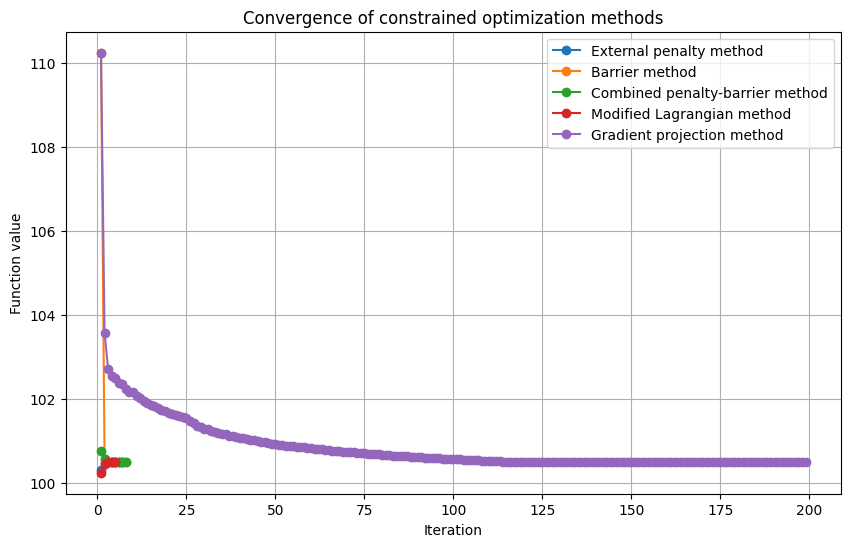

In [14]:
# Построение графика сходимости методов по значению целевой функции

plt.figure(figsize=(10, 6))

for result in all_results:
    f_values = [item["f_value"] for item in result["history"]]
    iterations = list(range(1, len(f_values) + 1))
    plt.plot(iterations, f_values, marker="o", label=result["method"])

plt.xlabel("Iteration")
plt.ylabel("Function value")
plt.title("Convergence of constrained optimization methods")
plt.grid(True)
plt.legend()
plt.show()

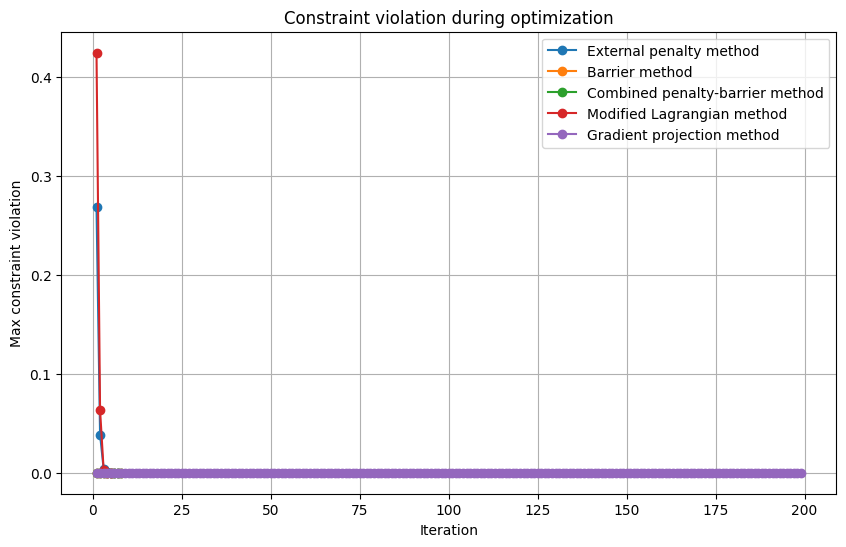

In [15]:
# Построение графика изменения нарушения ограничений по итерациям

plt.figure(figsize=(10, 6))

for result in all_results:
    violations = [item["constraint_violation"] for item in result["history"]]
    iterations = list(range(1, len(violations) + 1))
    plt.plot(iterations, violations, marker="o", label=result["method"])

plt.xlabel("Iteration")
plt.ylabel("Max constraint violation")
plt.title("Constraint violation during optimization")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
# Проверка найденных решений на допустимость ограничений

feasibility_data = []

for result in all_results:
    x = result["x"]
    g = constraints(x)

    feasibility_data.append({
        "Method": result["method"],
        "g1": g[0],
        "g2": g[1],
        "g3": g[2],
        "g4": g[3],
        "All constraints <= 0": np.all(g <= 1e-6)
    })

feasibility_table = pd.DataFrame(feasibility_data)

feasibility_table

,Method,g1,g2,g3,g4,All constraints <= 0
0,External penalty method,4.127106e-07,-0.754892,-0.570441,-0.323629,True
1,Barrier method,-1.215649e-04,-0.754865,-0.570398,-0.323580,True
2,Combined penalty-barrier method,-1.010674e-07,-0.754881,-0.570445,-0.323647,True
3,Modified Lagrangian method,7.074029e-08,-0.754893,-0.570440,-0.323628,True
4,Gradient projection method,-1.110223e-16,-0.754893,-0.570440,-0.323628,True


In [17]:
# Вывод итогового заключения по результатам вычислений

best_by_iterations = comparison_table.loc[comparison_table["Iterations"].idxmin()]
best_by_time = comparison_table.loc[comparison_table["Execution time"].idxmin()]
best_by_function = comparison_table.loc[comparison_table["Function value"].idxmin()]

print("Best method by number of iterations:", best_by_iterations["Method"])
print("Minimum iterations:", best_by_iterations["Iterations"])
print()

print("Best method by execution time:", best_by_time["Method"])
print("Minimum execution time:", best_by_time["Execution time"])
print()

print("Best method by function value:", best_by_function["Method"])
print("Minimum function value:", best_by_function["Function value"])
print()

print("Approximate constrained minimum point:")
print(best_by_function[["x1", "x2", "x3"]].values)

print()
print("All methods found feasible solutions:", comparison_table["Feasible"].all())

Best method by number of iterations: Modified Lagrangian method
Minimum iterations: 5

Best method by execution time: Gradient projection method
Minimum execution time: 0.0346522331237793

Best method by function value: External penalty method
Minimum function value: 100.48972020809242

Approximate constrained minimum point:
[np.float64(0.7548918044500967) np.float64(0.570441380742883)
 np.float64(0.32362850217619)]

All methods found feasible solutions: True
